---
title: Linear Regression
author: Andrei Akopian
date: 2026-02-14
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

Baseline linear regression for unmixing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sklearn

In [2]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[2]
sys.path.append(str(github_root))

from src.utils import helper_functions

In [3]:
ATMO_DATA = "../../../data/isprs_26_only_vza_rows.csv"
LAB_DATA = "../../../data/useful_columns_data.csv"

In [4]:
df = helper_functions.open_file(LAB_DATA)
fractions, nr900to1690_raw = helper_functions.take_subset(df,start=900,end=1690)

# Naive Linear Regression

A naive linear regression, without adjusting to the specifics of the dataset in anyway.

In [6]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1690_raw, fractions.to_numpy(), test_size=0.2, random_state=42)
naive_regression = sklearn.linear_model.Ridge(alpha=0.0)
naive_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware

,alpha,0.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


Naive linear regression sticks outside of the [0, 1] range.

In [5]:
ab_true_np_array = y_test
ab_predictions = naive_regression.predict(X_test)
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_predictions,
    model_name="Naive Linear Regression",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")
rmse = sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_predictions)
print(f"rmse = {rmse}")

NameError: name 'y_test' is not defined

We clip the predicted abundances to [0,1] range, and visually confirm that the fractions add up roughly to 1.

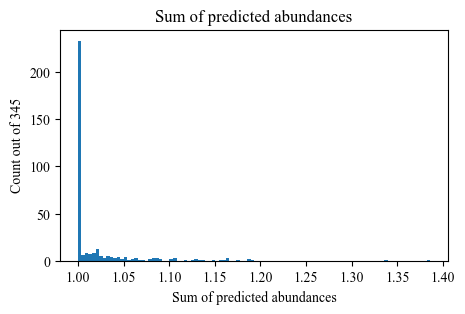

In [8]:
# | output: false
# | code-fold: true
ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
helper_functions.simple_histogram(ab_clipped_predictions.sum(axis=1), title="Sum of predicted abundances", x_label="Sum of predicted abundances", y_label=f"Count out of {y_test.shape[0]}", bins=100)

Clipped prediction plot:

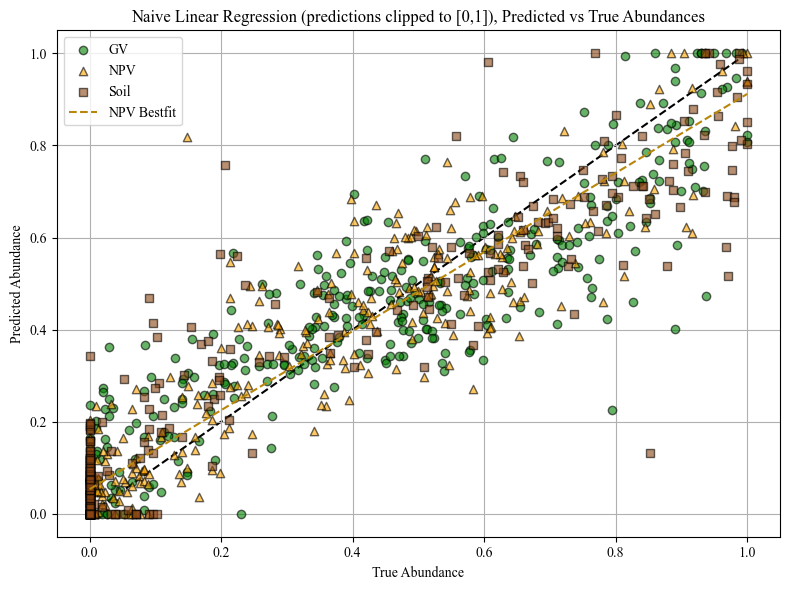

npv r^2 = 0.7902247995914948
gv r^2 = 0.8573417735794356
soil r^2 = 0.8793291115856579
mean r^2 = 0.8422985615855295
rmse = 0.13129861857119987


In [9]:
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_clipped_predictions,
    model_name="Naive Linear Regression (predictions clipped to [0,1])",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_clipped_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")
rmse = sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_predictions)
print(f"rmse = {rmse}")

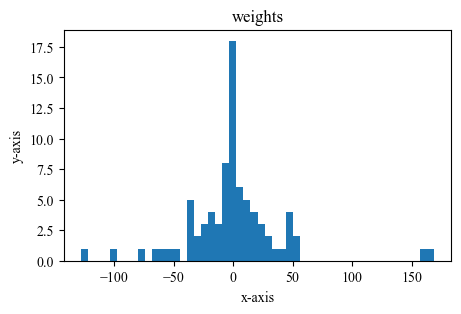

In [20]:
helper_functions.simple_histogram(naive_regression.coef_[0], bins=50, title="weights")

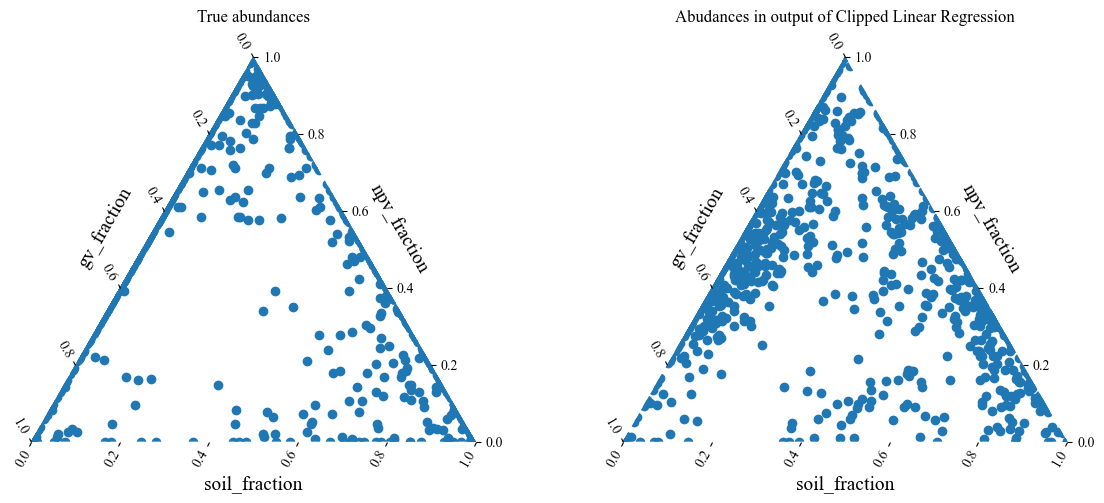

In [10]:
helper_functions.ternary_abundances(y_test, ab_clipped_predictions, model_name="Clipped Linear Regression")

## On Normalized Data
Here we do row wise $L_2$ normalization.

In [5]:
dataset = nr900to1690_raw
# norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
norms = dataset.sum(axis=1).to_numpy()
print(norms.min(), norms.max())
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
# post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
post_norms = normalized_dataset.sum(axis=1)
print(post_norms.min(), post_norms.max())
nr900to1690 = normalized_dataset

8.6551167051 44.43919789800001
0.9999999999999988 1.0000000000000009


In [6]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1690, fractions.to_numpy(), test_size=0.2, random_state=42)
normalized_regression = sklearn.linear_model.LinearRegression()
normalized_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


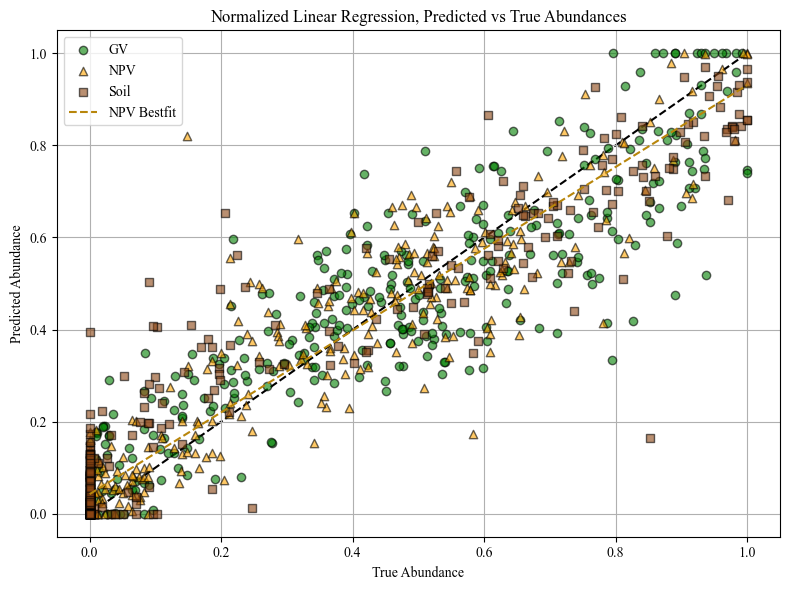

npv r^2 = 0.8141670724739376
gv r^2 = 0.8671650934141869
soil r^2 = 0.9025544338209334
mean r^2 = 0.8612955332363526
rmse = 0.11532366154403788


In [7]:
ab_true_np_array = y_test
ab_predictions = normalized_regression.predict(X_test)
ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
ab_clipnormed_predictions = ab_clipped_predictions / ab_clipped_predictions.sum(axis=1)[:, np.newaxis]
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_clipped_predictions,
    model_name="Normalized Linear Regression",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_clipnormed_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")
rmse = sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_clipnormed_predictions)
print(f"rmse = {rmse}")

### Checking Different Random States
Overly good result:
```
== State 11 ==
npv r^2 = 0.8277290383217878
gv r^2 = 0.8821844039292022
soil r^2 = 0.9205843854137392
mean r^2 = 0.8768326092215762
rmse = 0.10757869079633842
```
Midrange result:
```
== State 6 ==
npv r^2 = 0.7707717944115102
gv r^2 = 0.8860753980619638
soil r^2 = 0.8970468604819483
mean r^2 = 0.8512980176518075
rmse = 0.11553345351122202
```
Bad result:
```
== State 4 ==
npv r^2 = 0.728998683629316
gv r^2 = 0.8550228138493253
soil r^2 = 0.8944640342939832
mean r^2 = 0.8261618439242082
rmse = 0.12435319948311334
```

In [35]:
def check_random_state(random_state: int = 42, plot: bool = False, alpha: float = 0.0) -> tuple[float]:
    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1690, fractions.to_numpy(), test_size=0.2, random_state=random_state)
    normalized_regression = sklearn.linear_model.Ridge(alpha=alpha)
    normalized_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware
    ab_true_np_array = y_test
    ab_predictions = normalized_regression.predict(X_test)
    ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
    ab_clipnormed_predictions = ab_clipped_predictions / ab_clipped_predictions.sum(axis=1)[:, np.newaxis]
    if plot:
        helper_functions.plot_preds(
            ab_true=ab_true_np_array,
            ab_pred=ab_clipped_predictions,
            model_name=f"Normalized Linear Regression. random_state={random_state}",
            save_path=f"naive_linear_regression_randomstate{random_state}.svg"
        )
    slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_clipnormed_predictions)
    npvr2, gvr2, soilr2, rmse = r[0]**2, r[1]**2, r[2]**2, sklearn.metrics.root_mean_squared_error(ab_true_np_array, ab_clipnormed_predictions)

    # check training r^2
    train_predictions = normalized_regression.predict(X_train)
    train_clipped_predictions = np.clip(train_predictions, a_min=0, a_max=1)
    train_clipnormed_predictions = train_clipped_predictions / train_clipped_predictions.sum(axis=1)[:, np.newaxis]
    trainr2 = sklearn.metrics.r2_score(y_train, train_clipnormed_predictions)

    print(f"npv r2 = {npvr2} | gv r2 = {gvr2} | soil r2 = {soilr2} | mean = {(npvr2 + gvr2 + soilr2) / 3} | rmse={rmse} | train={trainr2}")
    return npvr2, gvr2, soilr2, rmse, trainr2

In [36]:
# Try differnet alpha values
random_state = 42
print("Normalized Lab Data. random_state =", random_state)
for alpha in np.arange(0.0, 1.0, 0.05):
    print("Alpha", round(alpha*alpha, 4))
    npvr2, gvr2, soilr2, rmse, trainr2 = check_random_state(alpha=alpha*alpha)

Normalized Lab Data. random_state = 42
Alpha 0.0
npv r2 = 0.8138591405448461 | gv r2 = 0.8671453120253905 | soil r2 = 0.9024699165874431 | mean = 0.8611581230525599 | rmse=0.11547679351243521 | train=0.8654115618037818
Alpha 0.0025
npv r2 = 0.46435315927110543 | gv r2 = 0.792369756519459 | soil r2 = 0.6049792538787717 | mean = 0.6205673898897787 | rmse=0.1914669938449597 | train=0.6307316590363546
Alpha 0.01
npv r2 = 0.3707458766098644 | gv r2 = 0.786032882843221 | soil r2 = 0.5099813079375268 | mean = 0.555586689130204 | rmse=0.20724629032979988 | train=0.5624429951487429
Alpha 0.0225
npv r2 = 0.30507637999964227 | gv r2 = 0.7823770237979867 | soil r2 = 0.4453784620781021 | mean = 0.5109439552919103 | rmse=0.21708275937476884 | train=0.5157760149458838
Alpha 0.04
npv r2 = 0.2485064103737366 | gv r2 = 0.7795167755316016 | soil r2 = 0.3978924223059457 | mean = 0.4753052027370946 | rmse=0.2239340089486402 | train=0.48185300065575193
Alpha 0.0625
npv r2 = 0.20518243209562612 | gv r2 = 0.7

In [37]:
npvr2s = []
gvr2s = []
soilr2s = []
rmses = []
trainr2s = []
N = 100
for state in range(0, N):
    # print(f"== State {state} ==")
    npvr2, gvr2, soilr2, rmse, trainr2 = check_random_state(state)
    npvr2s.append(npvr2)
    gvr2s.append(gvr2)
    soilr2s.append(soilr2)
    rmses.append(rmse)
    trainr2s.append(trainr2)

/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.31979e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.43564e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.65568e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.24379e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/s

npv r2 = 0.7746641001859524 | gv r2 = 0.8744328149424564 | soil r2 = 0.910041415311991 | mean = 0.8530461101468 | rmse=0.11371056614894336 | train=0.8669513929873244
npv r2 = 0.7812386178858216 | gv r2 = 0.8770225523348795 | soil r2 = 0.913177720669243 | mean = 0.8571462969633147 | rmse=0.11944227327018635 | train=0.866003303422023
npv r2 = 0.8032336714155659 | gv r2 = 0.9008934209059104 | soil r2 = 0.9212041178862399 | mean = 0.8751104034025721 | rmse=0.11294561519748335 | train=0.8615443117232818
npv r2 = 0.734250445656516 | gv r2 = 0.8461005197204051 | soil r2 = 0.8800902499983916 | mean = 0.8201470717917708 | rmse=0.12844429064965981 | train=0.8731969843576577
npv r2 = 0.7286376415432287 | gv r2 = 0.8537114035788685 | soil r2 = 0.8952931520394203 | mean = 0.8258807323871725 | rmse=0.12433876602671685 | train=0.8732506052093726
npv r2 = 0.7917404426780748 | gv r2 = 0.8946279448788823 | soil r2 = 0.8972577693771439 | mean = 0.8612087189780336 | rmse=0.1171976756720942 | train=0.86508

/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.59131e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.27576e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.96672e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.36439e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/s

npv r2 = 0.7937354194838553 | gv r2 = 0.898330474773998 | soil r2 = 0.8997916098628471 | mean = 0.8639525013735668 | rmse=0.11383001413494875 | train=0.8654457427501141
npv r2 = 0.7641074645882716 | gv r2 = 0.8408413755197296 | soil r2 = 0.9016726160512202 | mean = 0.8355404853864071 | rmse=0.12216235590412632 | train=0.870612062586202
npv r2 = 0.7878123065130814 | gv r2 = 0.8359050936090627 | soil r2 = 0.8926235932036066 | mean = 0.8387803311085836 | rmse=0.12252220137603538 | train=0.8700722136186498
npv r2 = 0.8112069402245539 | gv r2 = 0.8927374864249571 | soil r2 = 0.9118613483050706 | mean = 0.8719352583181937 | rmse=0.11185379862188129 | train=0.8625456875311971
npv r2 = 0.7773635062323184 | gv r2 = 0.843175107064259 | soil r2 = 0.8954362879944694 | mean = 0.8386583004303488 | rmse=0.12219026744367552 | train=0.8702807292218427
npv r2 = 0.7580951471671793 | gv r2 = 0.870919568254671 | soil r2 = 0.9132944713050303 | mean = 0.8474363955756269 | rmse=0.11764622296146053 | train=0.8

/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.0516e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.25765e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.70079e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.29808e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/sc

npv r2 = 0.7509190781417886 | gv r2 = 0.8571524069514322 | soil r2 = 0.899748623955318 | mean = 0.835940036349513 | rmse=0.12072148286732186 | train=0.8703189052902629
npv r2 = 0.7795628732701424 | gv r2 = 0.8949365013759414 | soil r2 = 0.9102642449014903 | mean = 0.8615878731825247 | rmse=0.11201892517197508 | train=0.8647780983970695
npv r2 = 0.7691797989051328 | gv r2 = 0.8599601390843312 | soil r2 = 0.8954843359618992 | mean = 0.8415414246504543 | rmse=0.1179702920481796 | train=0.8697398993581148
npv r2 = 0.7822827402765589 | gv r2 = 0.887941772226974 | soil r2 = 0.9048736068238256 | mean = 0.8583660397757861 | rmse=0.11438630768457059 | train=0.8665995758258728
npv r2 = 0.7654835870070413 | gv r2 = 0.8636625498535523 | soil r2 = 0.8856760954988185 | mean = 0.8382740774531374 | rmse=0.12250965721178975 | train=0.8700525695481977
npv r2 = 0.7777671390630345 | gv r2 = 0.8682763744092342 | soil r2 = 0.865712969178386 | mean = 0.8372521608835516 | rmse=0.1251192825883852 | train=0.868

/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.83694e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.31323e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.04013e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.31189e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/s

In [32]:
avg_npv = np.mean(npvr2s)
avg_gv = np.mean(gvr2s)
avg_soil = np.mean(soilr2s)
avg_rmse = np.mean(rmses)
avg_train = np.mean(trainr2s)
print(f"avg npv R2 = {avg_npv}, std={np.std(npvr2s)}")
print(f"avg gv R2 = {avg_gv}, std={np.std(gvr2s)}")
print(f"avg soil R2 = {avg_soil}, std={np.std(soilr2s)}")
print(f"avg rmse = {avg_rmse}, std={np.std(rmses)}")
print(f"avg mean R2 = {(avg_npv + avg_gv + avg_soil) / 3}, std={np.std((np.array(npvr2s) + np.array(gvr2s) + np.array(soilr2s)) / 3)}")
print(f"avg mean training R2 = {avg_train}, std={np.std(trainr2s)}")

avg npv R2 = 0.7800549582916019, std=0.020215927879603694
avg gv R2 = 0.8740682086913711, std=0.014492775740103792
avg soil R2 = 0.9068773906329025, std=0.012871704795147326
avg rmse = 0.11638462280754766, std=0.004293477332322449
avg mean R2 = 0.8536668525386252, std=0.012314639677613532
avg mean training R2 = 0.8665197793718731, std=0.002746208722573022


Text(0, 0.5, 'testing r^2')

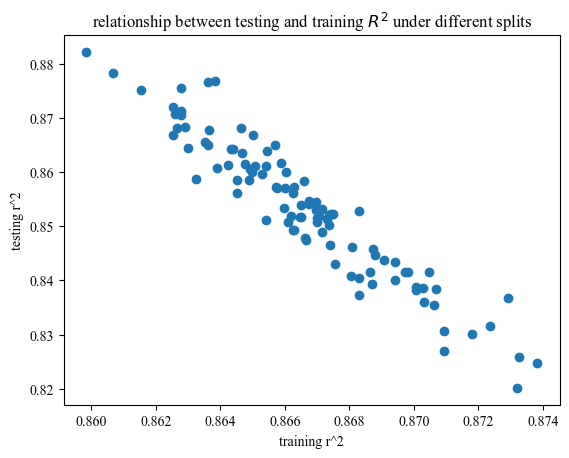

In [40]:
plt.scatter(trainr2s, (np.array(npvr2s) + np.array(gvr2s) + np.array(soilr2s)) / 3)
plt.title("relationship between testing and training $R^2$ under different splits")
plt.xlabel("training r^2")
plt.ylabel("testing r^2")

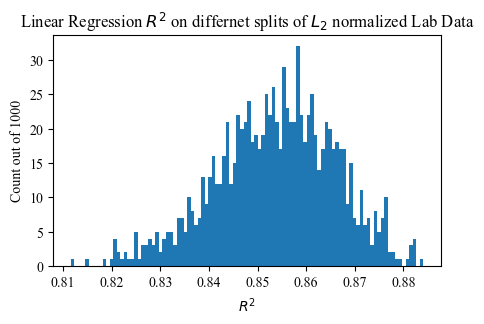

In [24]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.set_xlabel("$R^2$")
ax.set_ylabel(f"Count out of {N}")
ax.set_title("Linear Regression $R^2$ on differnet splits of $L_2$ normalized Lab Data")
ax.hist((np.array(npvr2s) + np.array(gvr2s) + np.array(soilr2s)) / 3, bins=100)
plt.savefig("lr_r2_splits_histogram.svg", format="svg")
plt.show()

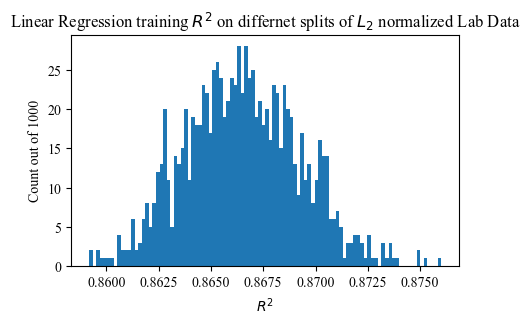

In [30]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.set_xlabel("$R^2$")
ax.set_ylabel(f"Count out of {N}")
ax.set_title("Linear Regression training $R^2$ on differnet splits of $L_2$ normalized Lab Data")
ax.hist(trainr2s, bins=100)
plt.savefig("lr_train_r2_splits_histogram.svg", format="svg")
plt.show()

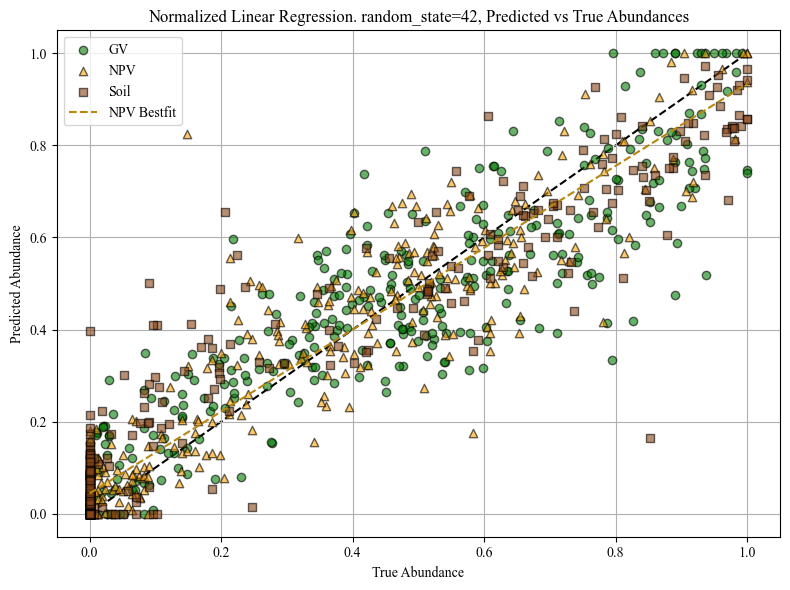

(np.float64(0.8138591405448461),
 np.float64(0.8671453120253905),
 np.float64(0.9024699165874431),
 0.11547679351243521,
 0.8654115618037818)

In [31]:
check_random_state(42, True)
# check_random_state(6, True)
# check_random_state(11, True)

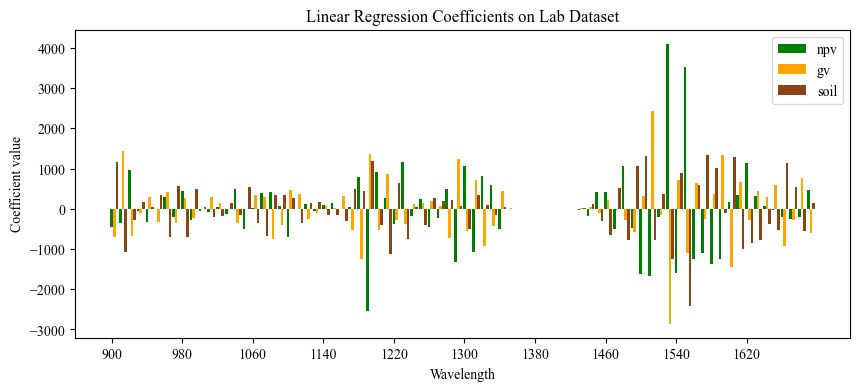

In [41]:
n = len(normalized_regression.coef_[0])

plt.figure(figsize=(10, 4))
bar_width = 0.3
x_range = np.arange(0, n, 1)
plt.bar(x_range + bar_width*0.0, normalized_regression.coef_[0], width=bar_width, label="npv", color='green')
plt.bar(x_range + bar_width*1, normalized_regression.coef_[1], width=bar_width, label="gv", color='orange')
plt.bar(x_range + bar_width*2, normalized_regression.coef_[2], width=bar_width, label="soil", color='saddlebrown')

step = max(1, n // 10)  # show ~10 labels
plt.xticks(range(0, n, step), nr900to1690_raw.columns[::step], rotation=0)
plt.xlabel("Wavelength")
plt.ylabel("Coefficient value")
plt.legend()

plt.title(f"Linear Regression Coefficients on Lab Dataset")
plt.savefig("lr_coefs_on_lab_data.svg", format="svg")

plt.show()

# Atmospheric Data

### Ridge Regression
The following demonstractions are best made using Ridge Regression. Note that Ridge Regression with `alpha=0.0` is equivalent to traditional Linear Regression.

In [21]:
df = helper_functions.open_file(ATMO_DATA)
at_fractions, at900to1690 = helper_functions.take_subset(df, 900, 1690)
assert all(at_fractions['gv_fraction'] == 0)
at_fractions = at_fractions[["npv_fraction", "soil_fraction"]]

In [22]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(at900to1690, at_fractions, test_size=0.2, random_state=42)
alpha = 0
ridge_regression = sklearn.linear_model.Ridge(alpha=alpha)
ridge_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware
print(ridge_regression.coef_[0])
print(f"Train r2: {ridge_regression.score(X_train, y_train)}")
print(f"Test r2: {ridge_regression.score(X_test, y_test)}")
y_pred = ridge_regression.predict(X_test)
rmse = sklearn.metrics.root_mean_squared_error(y_test, y_pred)
print(f"rmse = {rmse}")

[ -434.33624777   134.14424137   938.63531544   -53.86507464
   119.69315418  -577.5268749    310.59697368    -2.54641184
   240.07792217  -914.83212921    33.21940704  -522.77349417
  -343.12433333   334.45561204   852.27338298  -478.39990804
   338.89058688  1055.73186611  -438.6071534   -156.00315724
  -440.33065301   423.16785703  -429.21538517   328.48285632
   -99.13988815 -1014.99123805   144.81735052     4.65376474
  -194.69069996   110.1432552    558.09373805    96.33672824
   225.95009274  -449.96691285    81.8121202    -86.39659457
   -71.25510997  -716.84507714    63.54507525   484.61904215
   -93.33147729  -139.22527141   538.11279364  -217.51767876
   198.10830753    16.05024723    60.82980367     4.42222968
   199.20310625  -578.03610329  -284.28452266   138.21962632
   102.7583063    682.80774947  -171.3698701   1072.65306209
   -52.0422009   -292.00200324   481.25645946 -1034.05654531
  -124.07813832  -443.92585565   301.08202548  -325.69406232
   404.5194974    390.87

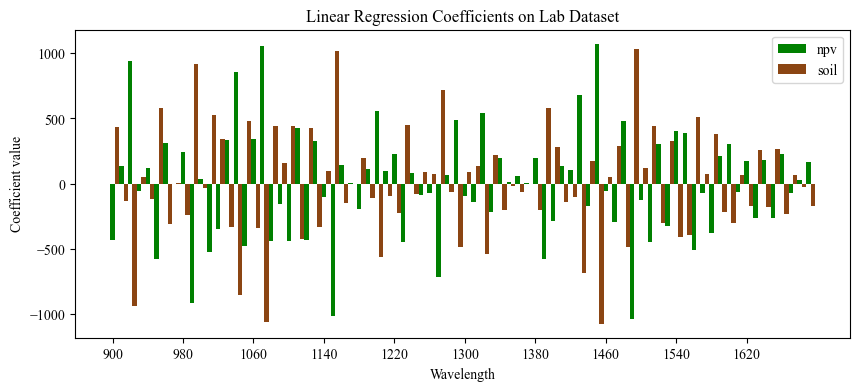

In [24]:
n = len(ridge_regression.coef_[0])

plt.figure(figsize=(10, 4))
bar_width = 0.5
x_range = np.arange(0, n, 1)
plt.bar(x_range + bar_width*0.0, ridge_regression.coef_[0], width=bar_width, label="npv", color='green')
plt.bar(x_range + bar_width*1, ridge_regression.coef_[1], width=bar_width, label="soil", color='saddlebrown')

step = max(1, n // 10)  # show ~10 labels
plt.xticks(range(0, n, step), nr900to1690_raw.columns[::step], rotation=0)
plt.xlabel("Wavelength")
plt.ylabel("Coefficient value")
plt.legend()

plt.title(f"Linear Regression Coefficients on Lab Dataset")
plt.savefig("lr_coefs_on_atmo_data.svg", format="svg")

plt.show()

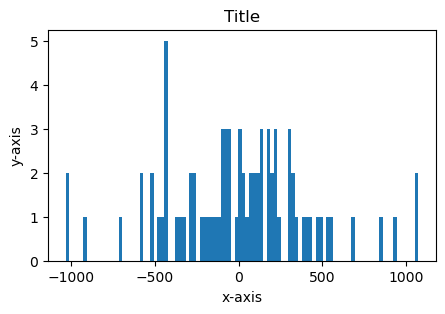

In [9]:
helper_functions.simple_histogram(ridge_regression.coef_[0], bins=100)

In [44]:
ab_true_np_array = y_test.to_numpy()
ab_predictions = ridge_regression.predict(X_test)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"soil r^2 = {r[1]**2}")
print(f"mean r^2 = {np.square(r).mean()}")

npv r^2 = 0.02107261229470254
soil r^2 = 0.02107261229456374
mean r^2 = 0.021072612294633142


### Pre-Training on Lab Data

**Result: Failure**, no meaningful predictive power.

In [45]:
lbdf = helper_functions.open_file(LAB_DATA)
lbfractions, lb900to1690_raw = helper_functions.take_subset(lbdf,start=900,end=1690)
atdf = helper_functions.open_file(ATMO_DATA)
atfractions, at900to1690_raw = helper_functions.take_subset(atdf,start=900,end=1690)

In [46]:
# L2 norm on lab data
dataset = lb900to1690_raw
norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
print(f"L1 before normalization: min={norms.min()} max={norms.max()}")
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
print(f"L1 after normalization: min={post_norms.min()} max={post_norms.max()}")
lb900to1690 = normalized_dataset

L1 before normalization: min=1.0853925339623511 max=4.995320587151579
L1 after normalization: min=0.9999999999999994 max=1.0000000000000007


In [47]:
# L2 norm on atmo data
dataset = at900to1690_raw
norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
print(f"L1 before normalization: min={norms.min()} max={norms.max()}")
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
print(f"L1 after normalization: min={post_norms.min()} max={post_norms.max()}")
at900to1690 = normalized_dataset

L1 before normalization: min=0.07422868006799167 max=5.547629854271101
L1 after normalization: min=0.9999999999999996 max=1.0000000000000002


with R² of -0.7696
- npv with an R² of -0.7701657533413415
- gv with an R² of 0.0
- soil with an R² of -0.7311657911405525
rmse = -0.5004438481606314


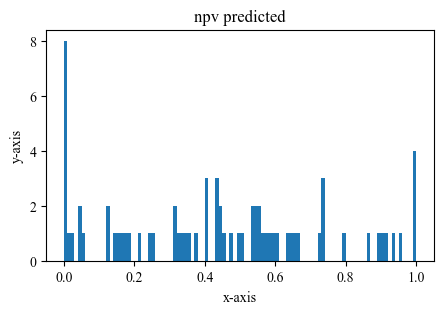

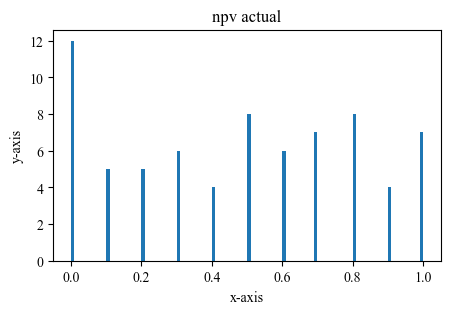

In [48]:
# Normal KNN regression
# should take <1min to run
r2_score = sklearn.metrics.r2_score
root_mean_squared_error = sklearn.metrics.r2_score

X_lb_train, y_lb_train = lb900to1690, lbfractions, 
X_at_train, X_test, y_at_train, y_test = sklearn.model_selection.train_test_split(at900to1690, atfractions, test_size=0.5, random_state=42)

X_train = np.concat([X_lb_train, X_at_train])
y_train = np.concat([y_lb_train, y_at_train])
factor = X_lb_train.shape[0] / y_at_train.shape[0]
sample_weight = [1] * X_lb_train.shape[0] + [factor] * X_at_train.shape[0]

lr = sklearn.linear_model.Ridge(alpha=0)
lr.fit(X_train, y_train, sample_weight=sample_weight)
y_pred = lr.predict(X_test)
current_r2 = r2_score(y_test, y_pred)

print(f"with R² of {current_r2:.4f}")

ab_true_np_array = y_test
ab_predictions = y_pred
ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
ab_clipnormed_predictions = ab_clipped_predictions / ab_clipped_predictions.sum(axis=1)[:, np.newaxis]
y_pred = ab_clipnormed_predictions

# y_pred = scipy.special.expit(y_pred)

helper_functions.simple_histogram([y[0] for y in y_pred ], title='npv predicted', bins=100)
helper_functions.simple_histogram([y_test.loc[i, 'npv_fraction'] for i in y_test.index], title='npv actual', bins=100)

print("- npv with an R² of", r2_score(y_test['npv_fraction'], [p[0] for p in y_pred]))
print("- gv with an R² of", r2_score(y_test['gv_fraction'], [p[1] for p in y_pred]))
print("- soil with an R² of", r2_score(y_test['soil_fraction'], [p[2] for p in y_pred]))
rmse = root_mean_squared_error(y_test, y_pred)
print(f"rmse = {rmse}")